In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "3544631"

print("="*60)
print("Oxford FEMaLe Dataset Exploration")
print("="*60)

print("Dataset Path :", DATASET_PATH)
print("Exists :", DATASET_PATH.exists())

Oxford FEMaLe Dataset Exploration
Dataset Path : c:\Users\Asus\OneDrive\Desktop\fetal_assesment_project\data\raw\3544631
Exists : True


In [2]:
all_files = sorted(DATASET_PATH.glob("*.mat"))

print(f"Total MAT files : {len(all_files)}")

for file in all_files:
    print(file.name)

Total MAT files : 32
154100_bp.mat
154100_signal.mat
450569_bp.mat
450569_signal.mat
450663_bp.mat
450663_signal.mat
451043_bp.mat
451043_signal.mat
451049_bp.mat
451049_signal.mat
451280_bp.mat
451280_signal.mat
451377_bp.mat
451377_signal.mat
451421_bp.mat
451421_signal.mat
451609_bp.mat
451609_signal.mat
451625_bp.mat
451625_signal.mat
451743_bp.mat
451743_signal.mat
451875_bp.mat
451875_signal.mat
451898_bp.mat
451898_signal.mat
451905_bp.mat
451905_signal.mat
451927_bp.mat
451927_signal.mat
451993_bp.mat
451993_signal.mat


In [3]:
signal_files = sorted(DATASET_PATH.glob("*signal*.mat"))
marker_files = sorted(DATASET_PATH.glob("*bp*.mat"))

print(f"Signal Files : {len(signal_files)}")
print(f"Marker Files : {len(marker_files)}")

Signal Files : 16
Marker Files : 16


In [4]:
sample_signal = signal_files[0]

mat = loadmat(sample_signal)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'BCG_PREPROC_3AXIS'])


In [7]:
sample_signal = signal_files[0]

mat = loadmat(sample_signal)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'BCG_PREPROC_3AXIS'])


In [8]:
for key in mat:
    
    if not key.startswith("__"):
        
        print(key)

        print(type(mat[key]))

        print(np.shape(mat[key]))

        print("-"*40)

BCG_PREPROC_3AXIS
<class 'numpy.ndarray'>
(154099, 3)
----------------------------------------


In [10]:
# Replace SIGNAL_VARIABLE after inspecting the previous output

signal = mat["BCG_PREPROC_3AXIS"]

print(signal.shape)

(154099, 3)


In [11]:
display(pd.DataFrame(signal).head())

,0,1,2
0,-11.118712,-10.677463,-16.522648
1,-11.119985,-10.676691,-16.522555
2,-11.120747,-10.679731,-16.525141
3,-11.122699,-10.682313,-16.522991
4,-11.123805,-10.683450,-16.521847


In [12]:
marker = loadmat(marker_files[0])

print(marker.keys())

dict_keys(['__header__', '__version__', '__globals__', 'BP_MOUV_FILES'])


In [13]:
for key in marker:
    
    if not key.startswith("__"):
        
        print(key)

        print(type(marker[key]))

        print(np.shape(marker[key]))

BP_MOUV_FILES
<class 'numpy.ndarray'>
(154100, 1)


In [15]:
stats = []

for file in signal_files:

    data = loadmat(file)

    # Replace SIGNAL_VARIABLE later

    signal = data["BCG_PREPROC_3AXIS"]

    stats.append({
        "Recording": file.stem,
        "Samples": signal.shape[0],
        "Channels": signal.shape[1]
    })

stats_df = pd.DataFrame(stats)

display(stats_df)

,Recording,Samples,Channels
0,154100_signal,154099,3
1,450569_signal,450569,3
2,450663_signal,450663,3
3,451043_signal,451042,3
4,451049_signal,451049,3
5,451280_signal,451280,3
6,451377_signal,451377,3
7,451421_signal,451421,3
8,451609_signal,451609,3
9,451625_signal,451625,3


In [ ]:
signal.shape

(451993, 3)

: 

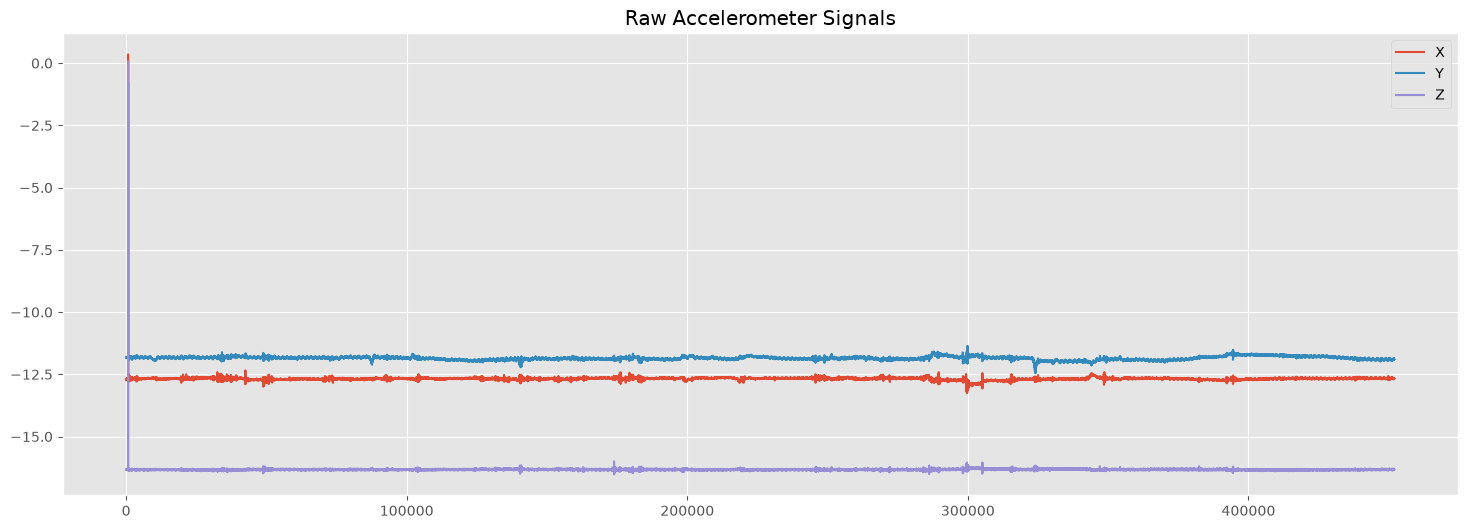

In [16]:
plt.figure(figsize=(18,6))

plt.plot(signal[:,0], label="X")
plt.plot(signal[:,1], label="Y")
plt.plot(signal[:,2], label="Z")

plt.legend()

plt.title("Raw Accelerometer Signals")

plt.show()

In [17]:
df = pd.DataFrame(signal, columns=["X","Y","Z"])

display(df.describe())

,X,Y,Z
count,451993.000000,451993.000000,451993.000000
mean,-12.679156,-11.852958,-16.323323
std,0.049683,0.071366,0.030425
min,-13.251168,-12.460249,-16.520012
25%,-12.697972,-11.896946,-16.333009
50%,-12.674272,-11.853290,-16.324025
75%,-12.654616,-11.810421,-16.314577
max,0.351666,-0.772895,0.061086


In [18]:
variance = df.var().sort_values(ascending=False)

display(variance)

Y    0.005093
X    0.002468
Z    0.000926
dtype: float64

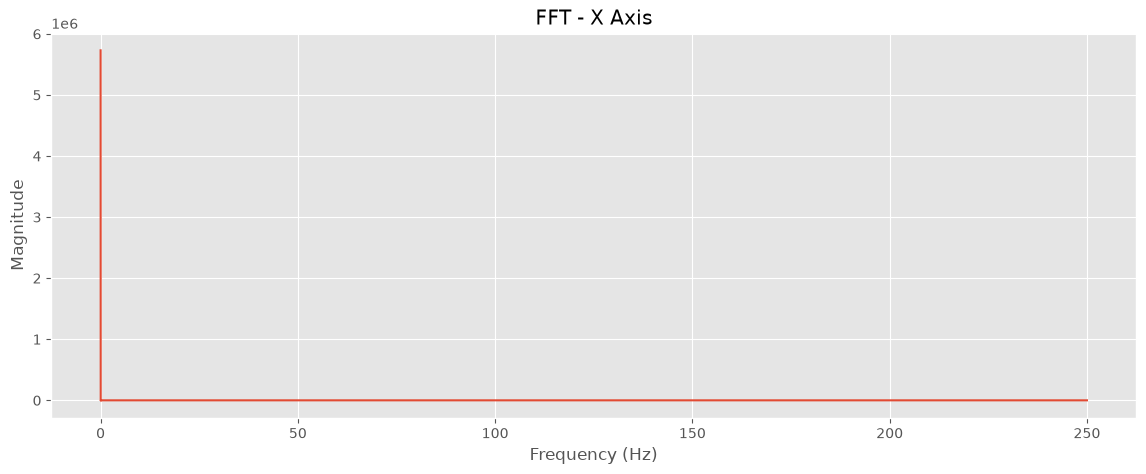

In [19]:
from scipy.fft import fft, fftfreq

N = len(signal)

Fs = 500

yf = fft(signal[:,0])

xf = fftfreq(N, 1/Fs)

plt.figure(figsize=(14,5))

plt.plot(xf[:N//2], np.abs(yf[:N//2]))

plt.xlabel("Frequency (Hz)")

plt.ylabel("Magnitude")

plt.title("FFT - X Axis")

plt.show()